# RawNet2 Parent Model Evaluation
Evaluates **Parent-1 (LA)** and **Parent-2 (ITW)** on the local validation set.

**Outputs**
- EER, AUC-ROC, Accuracy, Precision, Recall, F1
- ROC curves · Confusion matrices · Score distributions · t-SNE embeddings
- Per-file score CSVs saved to `eval_results/`


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/My Drive/ANN/DeepSecure-Forensics/")
print("Working directory:", os.getcwd())


Working directory: /content/drive/My Drive/ANN/DeepSecure-Forensics


In [3]:
import copy, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

import soundfile as sf
import librosa

from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
)
from sklearn.manifold import TSNE
from scipy.optimize import brentq
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

GREY    = '#9e9e9e'
LIGHT   = '#e0e0e0'

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {'cuda' if torch.cuda.is_available() else 'cpu'}")


PyTorch : 2.10.0+cu128
Device  : cuda


In [9]:
VAL_ROOT        = "datasets/validation_dataset"
PARENT1_WEIGHTS = "RawNet2 Parents/parent1_la/models/best_model.pth"
PARENT2_WEIGHTS = "RawNet2 Parents/parent2_itw/models/best_model.pth"
OUTPUT_DIR      = "eval_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
MAX_LEN    = 64600

D_ARGS = {
    'nb_classes': 2,
    'nb_fc_node': 1024,
    'gru_node': 1024,
    'nb_gru_layer': 3,
    'first_conv': 1024,
    'in_channels': 1,
    'filts': [128, [128, 128], [128, 512]],
}

MODEL_LABELS = {
    PARENT1_WEIGHTS: "Parent-1 (LA)",
    PARENT2_WEIGHTS: "Parent-2 (ITW)",
}

print("Config loaded.")
print(f"  VAL_ROOT : {VAL_ROOT}")
print(f"  OUTPUT   : {OUTPUT_DIR}")
print(f"  Device   : {DEVICE}")

Config loaded.
  VAL_ROOT : datasets/validation_dataset
  OUTPUT   : eval_results
  Device   : cuda


## Model Definition (RawNet2)

In [10]:
class SincConv(nn.Module):
    @staticmethod
    def to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        return 700 * (10 ** (mel / 2595) - 1)

    def __init__(self, device, out_channels, kernel_size, in_channels=1,
                 sample_rate=16000, stride=1, padding=0, dilation=1,
                 bias=False, groups=1, freq_scale='Mel'):
        super(SincConv, self).__init__()
        if in_channels != 1:
            raise ValueError("SincConv only supports one input channel.")
        self.out_channels = out_channels + 1
        self.kernel_size  = kernel_size if kernel_size % 2 != 0 else kernel_size + 1
        self.sample_rate  = sample_rate
        self.device       = device
        self.stride, self.padding, self.dilation = stride, padding, dilation

        NFFT = 512
        f = int(self.sample_rate / 2) * np.linspace(0, 1, int(NFFT / 2) + 1)

        if freq_scale == 'Mel':
            fmel = self.to_mel(f)
            filbandwidthsmel = np.linspace(np.min(fmel), np.max(fmel), self.out_channels + 2)
            self.freq = self.to_hz(filbandwidthsmel)[:self.out_channels]
        elif freq_scale == 'Inverse-mel':
            fmel = self.to_mel(f)
            filbandwidthsmel = np.linspace(np.min(fmel), np.max(fmel), self.out_channels + 2)
            mel = self.to_hz(filbandwidthsmel)[:self.out_channels]
            self.freq = np.abs(np.flip(mel) - 1)
        else:
            filbandwidthsmel = np.linspace(np.min(f), np.max(f), self.out_channels + 2)
            self.freq = filbandwidthsmel[:self.out_channels]

        self.hsupp     = torch.arange(-(self.kernel_size - 1) / 2, (self.kernel_size - 1) / 2 + 1)
        self.band_pass = torch.zeros(self.out_channels - 1, self.kernel_size)

    def forward(self, x):
        for i in range(len(self.freq) - 1):
            fmin  = self.freq[i]
            fmax  = self.freq[i + 1]
            hHigh = (2*fmax/self.sample_rate) * np.sinc(2*fmax*self.hsupp/self.sample_rate)
            hLow  = (2*fmin/self.sample_rate) * np.sinc(2*fmin*self.hsupp/self.sample_rate)
            self.band_pass[i, :] = Tensor(np.hamming(self.kernel_size)) * Tensor(hHigh - hLow)
        band_pass_filter = self.band_pass.to(self.device)
        self.filters = band_pass_filter.view(self.out_channels - 1, 1, self.kernel_size)
        return F.conv1d(x, self.filters, stride=self.stride,
                        padding=self.padding, dilation=self.dilation, bias=None, groups=1)


class Residual_block(nn.Module):
    def __init__(self, nb_filts, first=False):
        super(Residual_block, self).__init__()
        self.first = first
        if not self.first:
            self.bn1 = nn.BatchNorm1d(num_features=nb_filts[0])
        self.lrelu = nn.LeakyReLU(negative_slope=0.3)
        self.conv1 = nn.Conv1d(nb_filts[0], nb_filts[1], kernel_size=3, padding=1, stride=1)
        self.bn2   = nn.BatchNorm1d(num_features=nb_filts[1])
        self.conv2 = nn.Conv1d(nb_filts[1], nb_filts[1], kernel_size=3, padding=1, stride=1)
        self.downsample = nb_filts[0] != nb_filts[1]
        if self.downsample:
            self.conv_downsample = nn.Conv1d(nb_filts[0], nb_filts[1],
                                             kernel_size=1, padding=0, stride=1)
        self.mp = nn.MaxPool1d(3)

    def forward(self, x):
        identity = x
        out = x if self.first else self.lrelu(self.bn1(x))
        out = self.conv1(out)
        out = self.lrelu(self.bn2(out))
        out = self.conv2(out)
        if self.downsample:
            identity = self.conv_downsample(identity)
        out += identity
        return self.mp(out)


class RawNet(nn.Module):
    def __init__(self, d_args, device):
        super(RawNet, self).__init__()
        self.device = device
        self.Sinc_conv = SincConv(device=device,
                                  out_channels=d_args['filts'][0],
                                  kernel_size=d_args['first_conv'],
                                  in_channels=d_args['in_channels'],
                                  freq_scale='Mel')
        self.first_bn = nn.BatchNorm1d(num_features=d_args['filts'][0])
        self.selu     = nn.SELU(inplace=True)
        self.block0   = nn.Sequential(Residual_block(nb_filts=d_args['filts'][1], first=True))
        self.block1   = nn.Sequential(Residual_block(nb_filts=d_args['filts'][1]))
        self.block2   = nn.Sequential(Residual_block(nb_filts=d_args['filts'][2]))
        d_args['filts'][2][0] = d_args['filts'][2][1]
        self.block3   = nn.Sequential(Residual_block(nb_filts=d_args['filts'][2]))
        self.block4   = nn.Sequential(Residual_block(nb_filts=d_args['filts'][2]))
        self.block5   = nn.Sequential(Residual_block(nb_filts=d_args['filts'][2]))
        self.avgpool  = nn.AdaptiveAvgPool1d(1)

        def _attn(f): return nn.Sequential(nn.Linear(f, f))
        self.fc_attention0 = _attn(d_args['filts'][1][-1])
        self.fc_attention1 = _attn(d_args['filts'][1][-1])
        self.fc_attention2 = _attn(d_args['filts'][2][-1])
        self.fc_attention3 = _attn(d_args['filts'][2][-1])
        self.fc_attention4 = _attn(d_args['filts'][2][-1])
        self.fc_attention5 = _attn(d_args['filts'][2][-1])

        self.bn_before_gru = nn.BatchNorm1d(num_features=d_args['filts'][2][-1])
        self.gru = nn.GRU(input_size=d_args['filts'][2][-1],
                          hidden_size=d_args['gru_node'],
                          num_layers=d_args['nb_gru_layer'],
                          batch_first=True)
        self.fc1_gru = nn.Linear(d_args['gru_node'], d_args['nb_fc_node'])
        self.fc2_gru = nn.Linear(d_args['nb_fc_node'], d_args['nb_classes'], bias=True)
        self.sig     = nn.Sigmoid()

    def _attn_block(self, block, attn_fc, x):
        xb = block(x)
        y  = self.sig(attn_fc(self.avgpool(xb).view(xb.size(0), -1)))
        y  = y.view(y.size(0), y.size(1), -1)
        return xb * y + y

    def forward(self, x, y=None, is_test=False):
        nb_samp, len_seq = x.shape[0], x.shape[1]
        x = x.view(nb_samp, 1, len_seq)
        x = self.Sinc_conv(x)
        x = F.max_pool1d(torch.abs(x), 3)
        x = self.selu(self.first_bn(x))
        x = self._attn_block(self.block0, self.fc_attention0, x)
        x = self._attn_block(self.block1, self.fc_attention1, x)
        x = self._attn_block(self.block2, self.fc_attention2, x)
        x = self._attn_block(self.block3, self.fc_attention3, x)
        x = self._attn_block(self.block4, self.fc_attention4, x)
        x = self._attn_block(self.block5, self.fc_attention5, x)
        x = self.selu(self.bn_before_gru(x))
        x = x.permute(0, 2, 1)
        self.gru.flatten_parameters()
        x, _ = self.gru(x)
        x = x[:, -1, :]
        x = self.fc1_gru(x)
        x = self.fc2_gru(x)
        return F.softmax(x, dim=1) if is_test else x

print("RawNet2 defined.")


RawNet2 defined.


## Dataset & Utilities

In [11]:
def pad_random(x: np.ndarray, max_len: int = MAX_LEN) -> np.ndarray:
    x_len = x.shape[0]
    if x_len > max_len:
        stt = np.random.randint(x_len - max_len)
        return x[stt:stt + max_len]
    return np.tile(x, (int(max_len / x_len) + 1))[:max_len]


class ValidationDataset(Dataset):
    TARGET_SR = 16000

    def __init__(self, root_dir: str, max_len: int = MAX_LEN):
        self.root_dir = root_dir
        self.max_len  = max_len
        df = pd.read_csv(os.path.join(root_dir, 'meta.csv'))
        self.df     = df.reset_index(drop=True)
        self.n_real = int((self.df['label'] == 'real').sum())
        self.n_fake = int((self.df['label'] == 'fake').sum())
        print(f"  Dataset: {len(self.df)} samples  |  real={self.n_real}  fake={self.n_fake}")

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = os.path.join(self.root_dir, row['label'], row['filename'])
        x, sr = sf.read(path)
        if x.ndim > 1:
            x = x.mean(axis=1)
        if sr != self.TARGET_SR:
            x = librosa.resample(x, orig_sr=sr, target_sr=self.TARGET_SR)
        label = 1 if row['label'] == 'real' else 0
        return torch.FloatTensor(pad_random(x, self.max_len)), label, row['filename']


def collate_fn(batch):
    xs, labels, fnames = zip(*batch)
    return torch.stack(xs), torch.tensor(labels), list(fnames)


val_ds = ValidationDataset(VAL_ROOT)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=0, collate_fn=collate_fn)
print(f"  DataLoader: {len(val_dl)} batches of up to {BATCH_SIZE}")


  Dataset: 102 samples  |  real=51  fake=51
  DataLoader: 7 batches of up to 16


## Model Loader & Evaluation Function

In [12]:
def load_rawnet2(weights_path: str) -> RawNet:
    args  = copy.deepcopy(D_ARGS)
    model = RawNet(args, DEVICE).to(DEVICE)
    ckpt  = torch.load(weights_path, map_location=DEVICE)

    if isinstance(ckpt, dict):
        # Try keys in priority order
        state = (ckpt.get('model_state_dict')
              or ckpt.get('model')
              or ckpt.get('state_dict')
              or ckpt)
    else:
        state = ckpt

    # Strip DataParallel 'module.' prefix if present
    state = {k.replace('module.', ''): v for k, v in state.items()}
    model.load_state_dict(state, strict=True)
    model.eval()
    print(f"  Loaded: {weights_path}")
    return model


@torch.no_grad()
def evaluate_model(model: RawNet, dataloader: DataLoader):
    all_scores, all_labels, all_fnames = [], [], []
    emb_list = []
    emb_buf  = []

    def _hook(module, inp, out):
        emb_buf.append(out.detach().cpu())

    handle = model.fc1_gru.register_forward_hook(_hook)

    for x, labels, fnames in tqdm(dataloader, desc="Inference", leave=False):
        emb_buf.clear()
        logits = model(x.to(DEVICE), is_test=False)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_scores.extend(probs.tolist())
        all_labels.extend(labels.numpy().tolist())
        all_fnames.extend(fnames)
        if emb_buf:
            emb_list.append(emb_buf[0])

    handle.remove()
    embeddings = torch.cat(emb_list, dim=0).numpy() if emb_list else np.array([])
    return np.array(all_scores), np.array(all_labels), all_fnames, embeddings

print("Utilities ready.")


Utilities ready.


## Run Evaluation on Both Parents

In [13]:
results = {}

for weights_path, label in MODEL_LABELS.items():
    print(f"\n{'='*55}")
    print(f"  Evaluating: {label}")
    print(f"{'='*55}")
    model = load_rawnet2(weights_path)
    scores, labels, fnames, embeddings = evaluate_model(model, val_dl)
    results[label] = {
        'scores'    : scores,
        'labels'    : labels,
        'fnames'    : fnames,
        'embeddings': embeddings,
    }
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"  Done — {len(scores)} samples  |  score range [{scores.min():.4f}, {scores.max():.4f}]")

print("\nEvaluation complete.")



  Evaluating: Parent-1 (LA)
  Loaded: RawNet2 Parents/parent1_la/models/best_model.pth


Inference:   0%|          | 0/7 [00:00<?, ?it/s]

  Done — 102 samples  |  score range [0.0003, 0.9994]

  Evaluating: Parent-2 (ITW)
  Loaded: RawNet2 Parents/parent2_itw/models/best_model.pth


Inference:   0%|          | 0/7 [00:00<?, ?it/s]

  Done — 102 samples  |  score range [0.0279, 0.9018]

Evaluation complete.


## Metrics Computation

In [14]:
def compute_metrics(labels: np.ndarray, scores: np.ndarray) -> dict:
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    fnr     = 1 - tpr

    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.) * 100
    except Exception:
        eer = fpr[np.nanargmin(np.abs(fnr - fpr))] * 100

    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    preds = (scores >= eer_threshold).astype(int)
    cm    = confusion_matrix(labels, preds)

    return {
        'eer'          : round(eer, 4),
        'auc'          : round(roc_auc, 6),
        'accuracy'     : round(accuracy_score(labels, preds) * 100, 4),
        'precision'    : round(precision_score(labels, preds, zero_division=0), 6),
        'recall'       : round(recall_score(labels, preds, zero_division=0), 6),
        'f1'           : round(f1_score(labels, preds, zero_division=0), 6),
        'cm'           : cm,
        'fpr'          : fpr,
        'tpr'          : tpr,
        'thresholds'   : thresholds,
        'eer_threshold': eer_threshold,
    }


metrics = {}
for label, res in results.items():
    m = compute_metrics(res['labels'], res['scores'])
    metrics[label] = m
    print(f"\n── {label} ──")
    print(f"  EER       : {m['eer']:.2f} %")
    print(f"  AUC-ROC   : {m['auc']:.4f}")
    print(f"  Accuracy  : {m['accuracy']:.2f} %  (@ EER threshold)")
    print(f"  Precision : {m['precision']:.4f}")
    print(f"  Recall    : {m['recall']:.4f}")
    print(f"  F1        : {m['f1']:.4f}")
    print(f"  Confusion :\n{m['cm']}")



── Parent-1 (LA) ──
  EER       : 58.82 %
  AUC-ROC   : 0.3987
  Accuracy  : 41.18 %  (@ EER threshold)
  Precision : 0.4118
  Recall    : 0.4118
  F1        : 0.4118
  Confusion :
[[21 30]
 [30 21]]

── Parent-2 (ITW) ──
  EER       : 49.02 %
  AUC-ROC   : 0.5129
  Accuracy  : 50.98 %  (@ EER threshold)
  Precision : 0.5098
  Recall    : 0.5098
  F1        : 0.5098
  Confusion :
[[26 25]
 [25 26]]


## Plot — ROC Curves

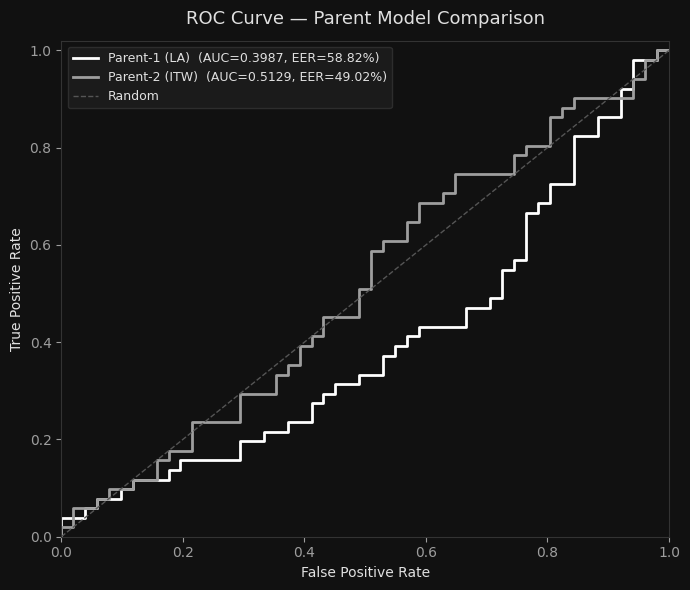

Saved → eval_results/roc_curves.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor='#111111')
ax.set_facecolor('#111111')
colors = ['#ffffff', '#9e9e9e']

for (label, m), color in zip(metrics.items(), colors):
    ax.plot(m['fpr'], m['tpr'], lw=2, color=color,
            label=f"{label}  (AUC={m['auc']:.4f}, EER={m['eer']:.2f}%)")

ax.plot([0, 1], [0, 1], '--', lw=1, color='#555555', label='Random')
ax.set_xlabel('False Positive Rate', color=LIGHT)
ax.set_ylabel('True Positive Rate', color=LIGHT)
ax.set_title('ROC Curve — Parent Model Comparison', color=LIGHT, fontsize=13, pad=12)
ax.tick_params(colors=GREY)
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.legend(facecolor='#1e1e1e', edgecolor='#333333', labelcolor=LIGHT, fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print("Saved → eval_results/roc_curves.png")


## Plot — Confusion Matrices

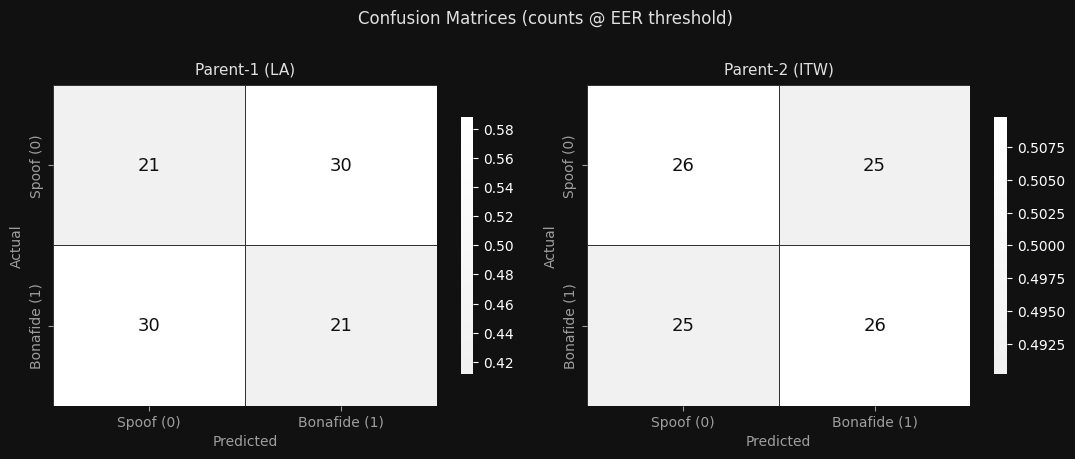

Saved → eval_results/confusion_matrices.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor='#111111')
cmap = sns.light_palette('#ffffff', as_cmap=True)

for ax, (label, m) in zip(axes, metrics.items()):
    ax.set_facecolor('#111111')
    cm_norm = m['cm'].astype('float') / m['cm'].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=m['cm'], fmt='d', cmap=cmap, ax=ax,
        linewidths=0.5, linecolor='#333333',
        xticklabels=['Spoof (0)', 'Bonafide (1)'],
        yticklabels=['Spoof (0)', 'Bonafide (1)'],
        annot_kws={'color': '#111111', 'fontsize': 13},
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(label, color=LIGHT, fontsize=11, pad=8)
    ax.set_xlabel('Predicted', color=GREY)
    ax.set_ylabel('Actual', color=GREY)
    ax.tick_params(colors=GREY)

plt.suptitle('Confusion Matrices (counts @ EER threshold)', color=LIGHT, fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print("Saved → eval_results/confusion_matrices.png")


## Plot — Score Distributions

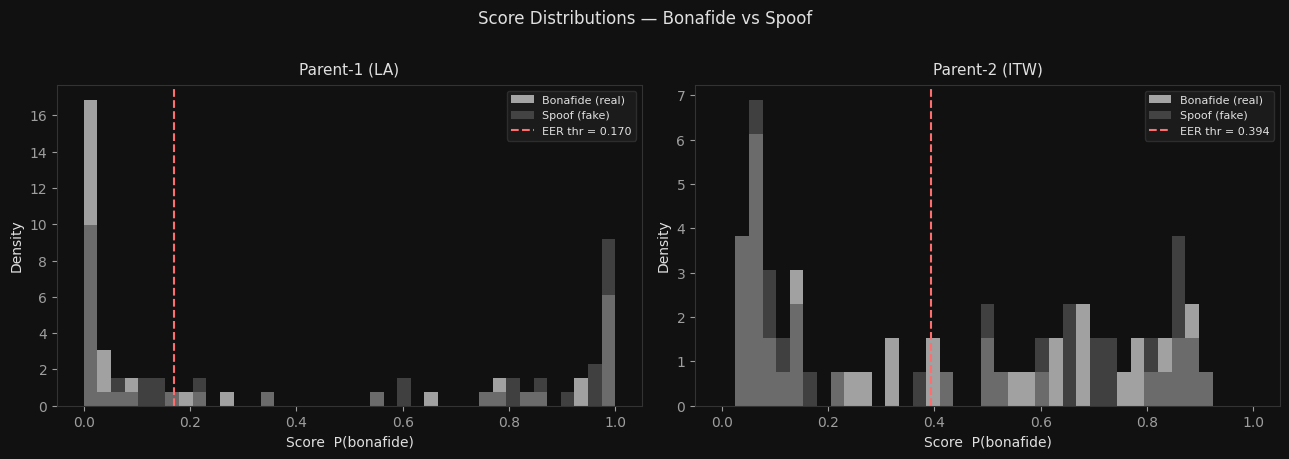

Saved → eval_results/score_distributions.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='#111111')

for ax, (model_label, res) in zip(axes, results.items()):
    scores  = res['scores']
    labels  = res['labels']
    m       = metrics[model_label]
    bins    = np.linspace(0, 1, 40)

    ax.set_facecolor('#111111')
    ax.hist(scores[labels == 1], bins=bins, alpha=0.7, color='#e0e0e0',
            label='Bonafide (real)', density=True)
    ax.hist(scores[labels == 0], bins=bins, alpha=0.7, color='#555555',
            label='Spoof (fake)', density=True)
    ax.axvline(m['eer_threshold'], color='#ff6e6e', lw=1.5, ls='--',
               label=f"EER thr = {m['eer_threshold']:.3f}")
    ax.set_xlabel('Score  P(bonafide)', color=LIGHT)
    ax.set_ylabel('Density', color=LIGHT)
    ax.set_title(model_label, color=LIGHT, fontsize=11, pad=8)
    ax.tick_params(colors=GREY)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    ax.legend(facecolor='#1e1e1e', edgecolor='#333333', labelcolor=LIGHT, fontsize=8)

plt.suptitle('Score Distributions — Bonafide vs Spoof', color=LIGHT, fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'score_distributions.png'), dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print("Saved → eval_results/score_distributions.png")


## Plot — t-SNE Embeddings (fc1_gru)

  t-SNE: Parent-1 (LA)  (102 samples, dim=1024)...
  t-SNE: Parent-2 (ITW)  (102 samples, dim=1024)...


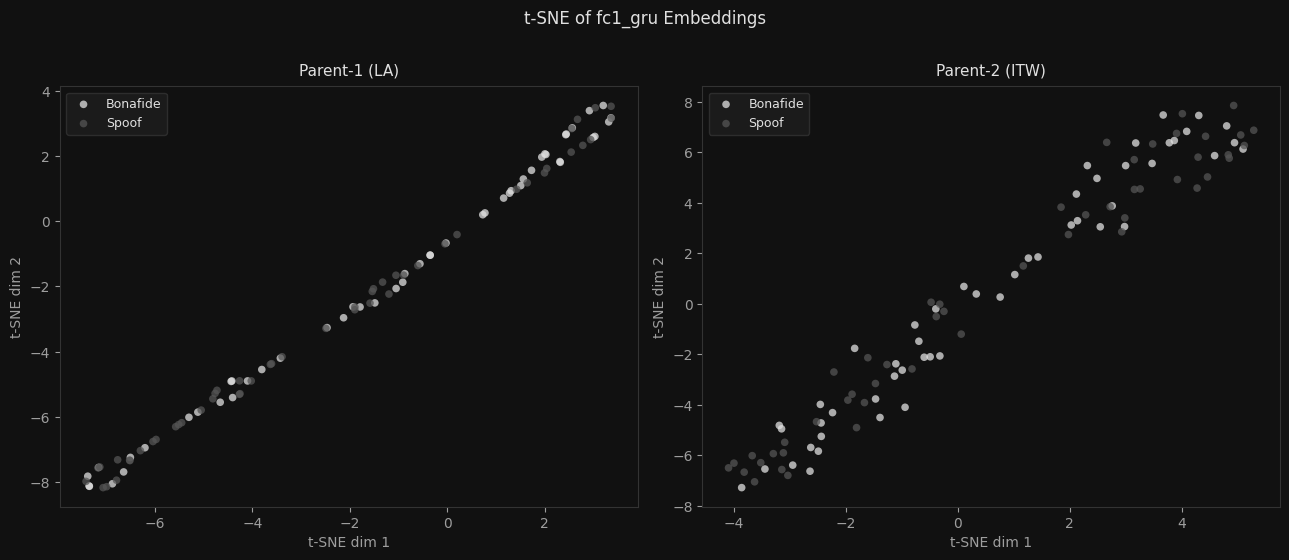

Saved → eval_results/tsne_embeddings.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='#111111')

for ax, (model_label, res) in zip(axes, results.items()):
    embs   = res['embeddings']
    labels = res['labels']
    print(f"  t-SNE: {model_label}  ({embs.shape[0]} samples, dim={embs.shape[1]})...")
    tsne = TSNE(n_components=2, perplexity=min(30, len(embs) - 1),
                random_state=42, max_iter=1000)
    z    = tsne.fit_transform(embs)

    ax.set_facecolor('#111111')
    ax.scatter(z[labels == 1, 0], z[labels == 1, 1],
               c='#e0e0e0', s=30, alpha=0.75, label='Bonafide', edgecolors='none')
    ax.scatter(z[labels == 0, 0], z[labels == 0, 1],
               c='#555555', s=30, alpha=0.75, label='Spoof', edgecolors='none')
    ax.set_title(model_label, color=LIGHT, fontsize=11, pad=8)
    ax.set_xlabel('t-SNE dim 1', color=GREY)
    ax.set_ylabel('t-SNE dim 2', color=GREY)
    ax.tick_params(colors=GREY)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    ax.legend(facecolor='#1e1e1e', edgecolor='#333333', labelcolor=LIGHT, fontsize=9)

plt.suptitle('t-SNE of fc1_gru Embeddings', color=LIGHT, fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_embeddings.png'), dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()
print("Saved → eval_results/tsne_embeddings.png")


## Per-File Score CSVs

In [19]:
for model_label, res in results.items():
    m       = metrics[model_label]
    scores  = res['scores']
    labels  = res['labels']
    fnames  = res['fnames']
    preds   = (scores >= m['eer_threshold']).astype(int)
    correct = (preds == labels).astype(int)

    df_out = pd.DataFrame({
        'filename'       : fnames,
        'true_label'     : ['bonafide' if l == 1 else 'spoof' for l in labels],
        'score_bonafide' : scores.round(6),
        'predicted_label': ['bonafide' if p == 1 else 'spoof' for p in preds],
        'correct'        : correct,
    })

    slug     = model_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    out_path = os.path.join(OUTPUT_DIR, f'scores_{slug}.csv')
    df_out.to_csv(out_path, index=False)
    print(f"  {model_label}: {correct.sum()}/{len(df_out)} correct  →  {out_path}")

print("\nPer-file CSVs saved.")


  Parent-1 (LA): 42/102 correct  →  eval_results/scores_parent-1_la.csv
  Parent-2 (ITW): 52/102 correct  →  eval_results/scores_parent-2_itw.csv

Per-file CSVs saved.


## Summary — Side-by-Side Metrics

In [20]:
summary_rows = []
for model_label, m in metrics.items():
    summary_rows.append({
        'Model'       : model_label,
        'EER (%)'     : m['eer'],
        'AUC-ROC'     : m['auc'],
        'Accuracy (%)': m['accuracy'],
        'Precision'   : m['precision'],
        'Recall'      : m['recall'],
        'F1 Score'    : m['f1'],
    })

df_summary = pd.DataFrame(summary_rows).set_index('Model')
display(df_summary.style
    .format({'EER (%)': '{:.2f}', 'AUC-ROC': '{:.4f}',
             'Accuracy (%)': '{:.2f}', 'Precision': '{:.4f}',
             'Recall': '{:.4f}', 'F1 Score': '{:.4f}'})
    .highlight_min(subset=['EER (%)'], color='#c8e6c9')
    .highlight_max(subset=['AUC-ROC', 'Accuracy (%)', 'Precision', 'Recall', 'F1 Score'],
                   color='#c8e6c9')
)

out_path = os.path.join(OUTPUT_DIR, 'summary_metrics.csv')
df_summary.to_csv(out_path)
print(f"Summary saved → {out_path}")
print("\n── All outputs in eval_results/ ──")
for f in sorted(Path(OUTPUT_DIR).iterdir()):
    print(f"  {f.name}")


,EER (%),AUC-ROC,Accuracy (%),Precision,Recall,F1 Score
Model,,,,,,
Parent-1 (LA),58.82,0.3987,41.18,0.4118,0.4118,0.4118
Parent-2 (ITW),49.02,0.5129,50.98,0.5098,0.5098,0.5098


Summary saved → eval_results/summary_metrics.csv

── All outputs in eval_results/ ──
  confusion_matrices.png
  roc_curves.png
  score_distributions.png
  scores_parent-1_la.csv
  scores_parent-2_itw.csv
  summary_metrics.csv
  tsne_embeddings.png
